In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
sales_data = pd.read_csv('/content/drive/MyDrive/datasets/Walmart_Sales.csv')

In [11]:
sales_df = sales_data.copy()

In [12]:
sales_df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [13]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [14]:
# check missing values
sales_df.isnull().sum().sort_values(ascending=False)

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [15]:
# check duplicated row
sales_df.duplicated().sum()

np.int64(0)

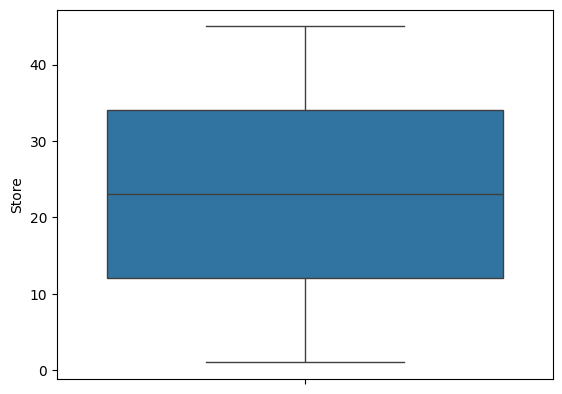

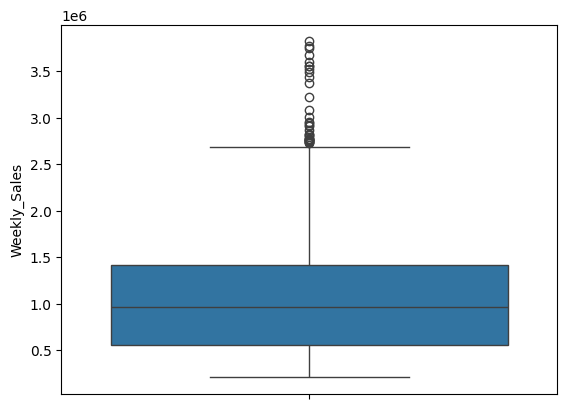

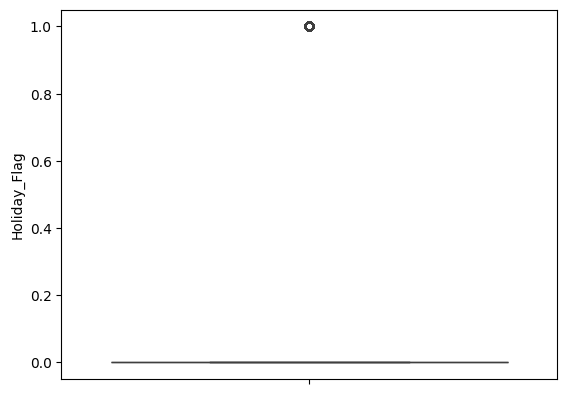

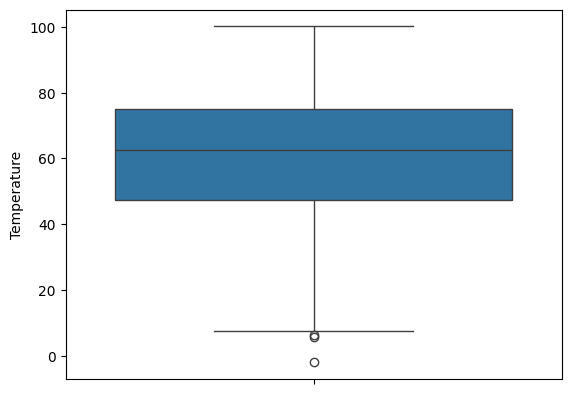

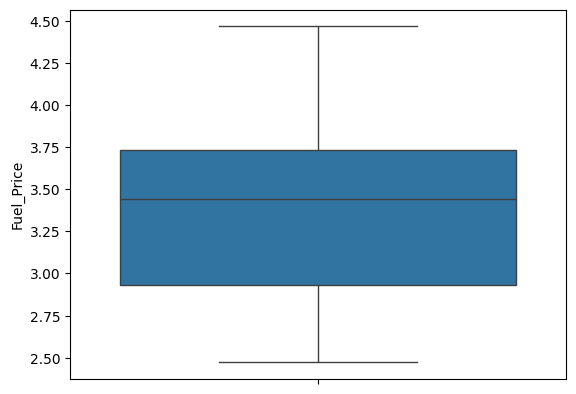

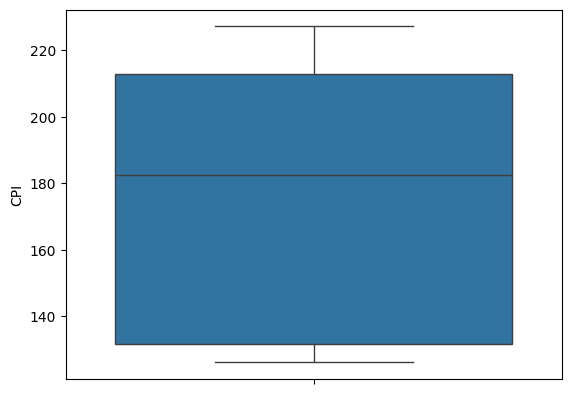

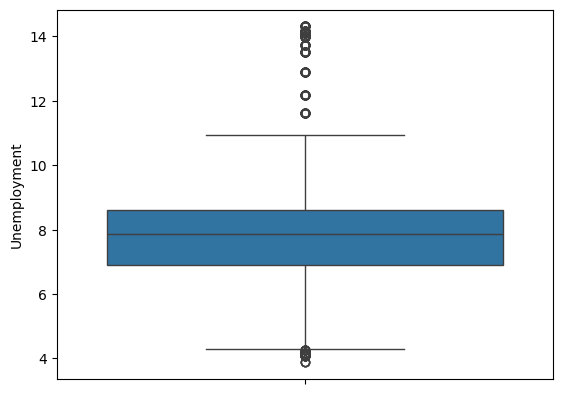

In [16]:
# only non object feature
numeric_feature = sales_df.select_dtypes(exclude='object')
for feature in numeric_feature:
  sns.boxplot(sales_df[feature])
  plt.show()

In [18]:
# Convert date from object to date format
sales_df['Date'] = pd.to_datetime(sales_df['Date'], format='%d-%m-%Y')

In [19]:
sales_df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [20]:
sales_df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000
std,12.988182,NaN,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885


In [24]:
# Convert fahrenheit to celcius
sales_df['Temperature (C)'] = (sales_df['Temperature'] - 32) * 5/9

In [25]:
sales_df.describe()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Temperature (C)
count,6435.000000,6435,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,2011-06-17 00:00:00,1.046965e+06,0.069930,15.924324,3.358607,171.578394,7.999151,-8.930931
min,1.000000,2010-02-05 00:00:00,2.099862e+05,0.000000,-18.922222,2.472000,126.064000,3.879000,-28.290123
25%,12.000000,2010-10-08 00:00:00,5.533501e+05,0.000000,8.588889,2.933000,131.735000,6.891000,-13.006173
50%,23.000000,2011-06-17 00:00:00,9.607460e+05,0.000000,17.038889,3.445000,182.616521,7.874000,-8.311728
75%,34.000000,2012-02-24 00:00:00,1.420159e+06,0.000000,23.855556,3.735000,212.743293,8.622000,-4.524691
max,45.000000,2012-10-26 00:00:00,3.818686e+06,1.000000,37.855556,4.468000,227.232807,14.313000,3.253086
std,12.988182,NaN,5.643666e+05,0.255049,10.247185,0.459020,39.356712,1.875885,5.692881


In [27]:
sales_df.drop('Temperature', axis =1, inplace= True)

In [28]:
sales_df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Fuel_Price,CPI,Unemployment,Temperature (C)
0,1,2010-02-05,1643690.90,0,2.572,211.096358,8.106,-14.595679
1,1,2010-02-12,1641957.44,1,2.548,211.242170,8.106,-15.768519
2,1,2010-02-19,1611968.17,0,2.514,211.289143,8.106,-15.330247
3,1,2010-02-26,1409727.59,0,2.561,211.319643,8.106,-13.262346
4,1,2010-03-05,1554806.68,0,2.625,211.350143,8.106,-13.302469


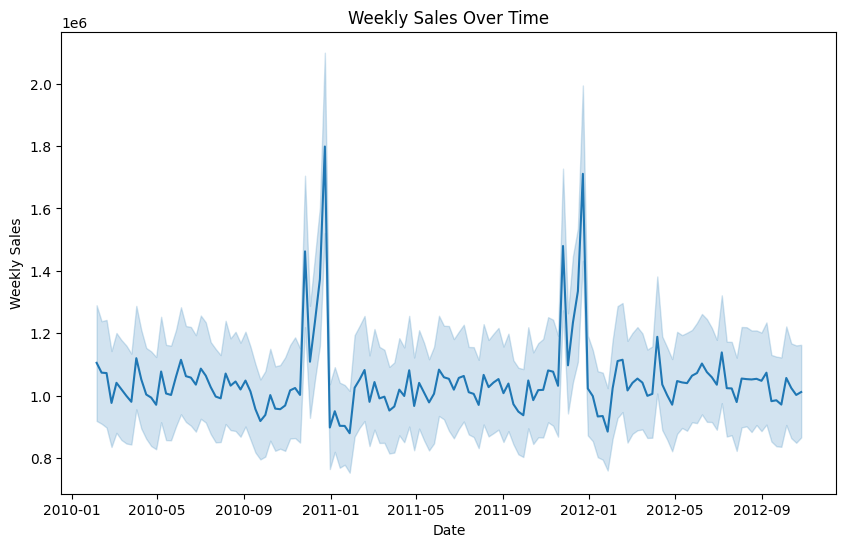

In [37]:
fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(x='Date', y='Weekly_Sales', data=sales_df, ax=ax)
ax.set_title('Weekly Sales Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Weekly Sales')
plt.show()

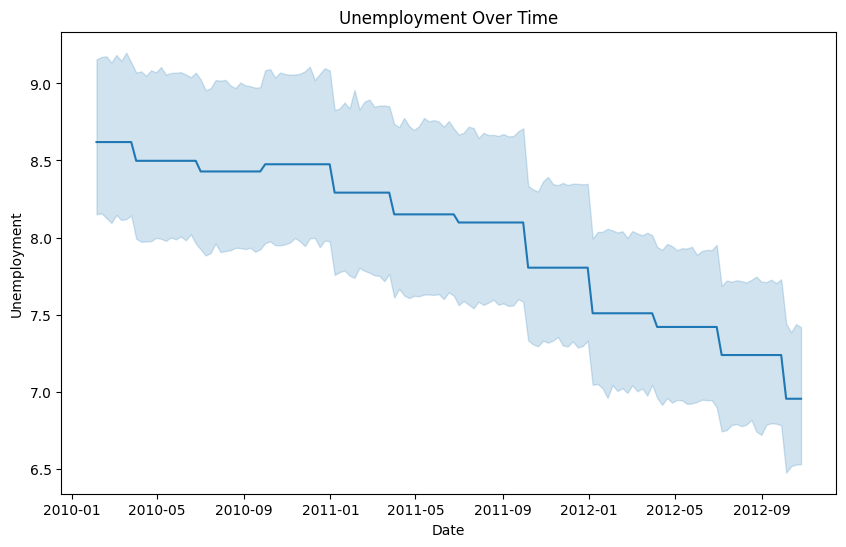

In [51]:
fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(x='Date', y='Unemployment', data=sales_df, ax=ax)
ax.set_title('Unemployment Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Unemployment')
plt.show()

<Axes: >

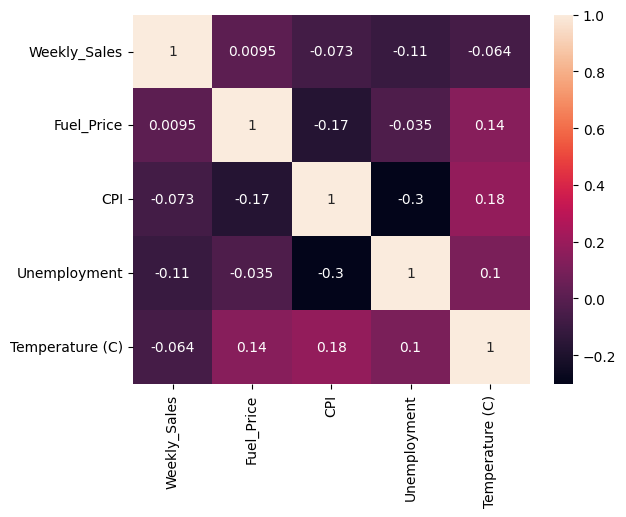

In [30]:
# Crate a heatmap to look at correlations
weekly_sales = sales_df.drop(['Store', 'Date', 'Holiday_Flag'], axis =1)
sns.heatmap(weekly_sales.corr(), annot=True)

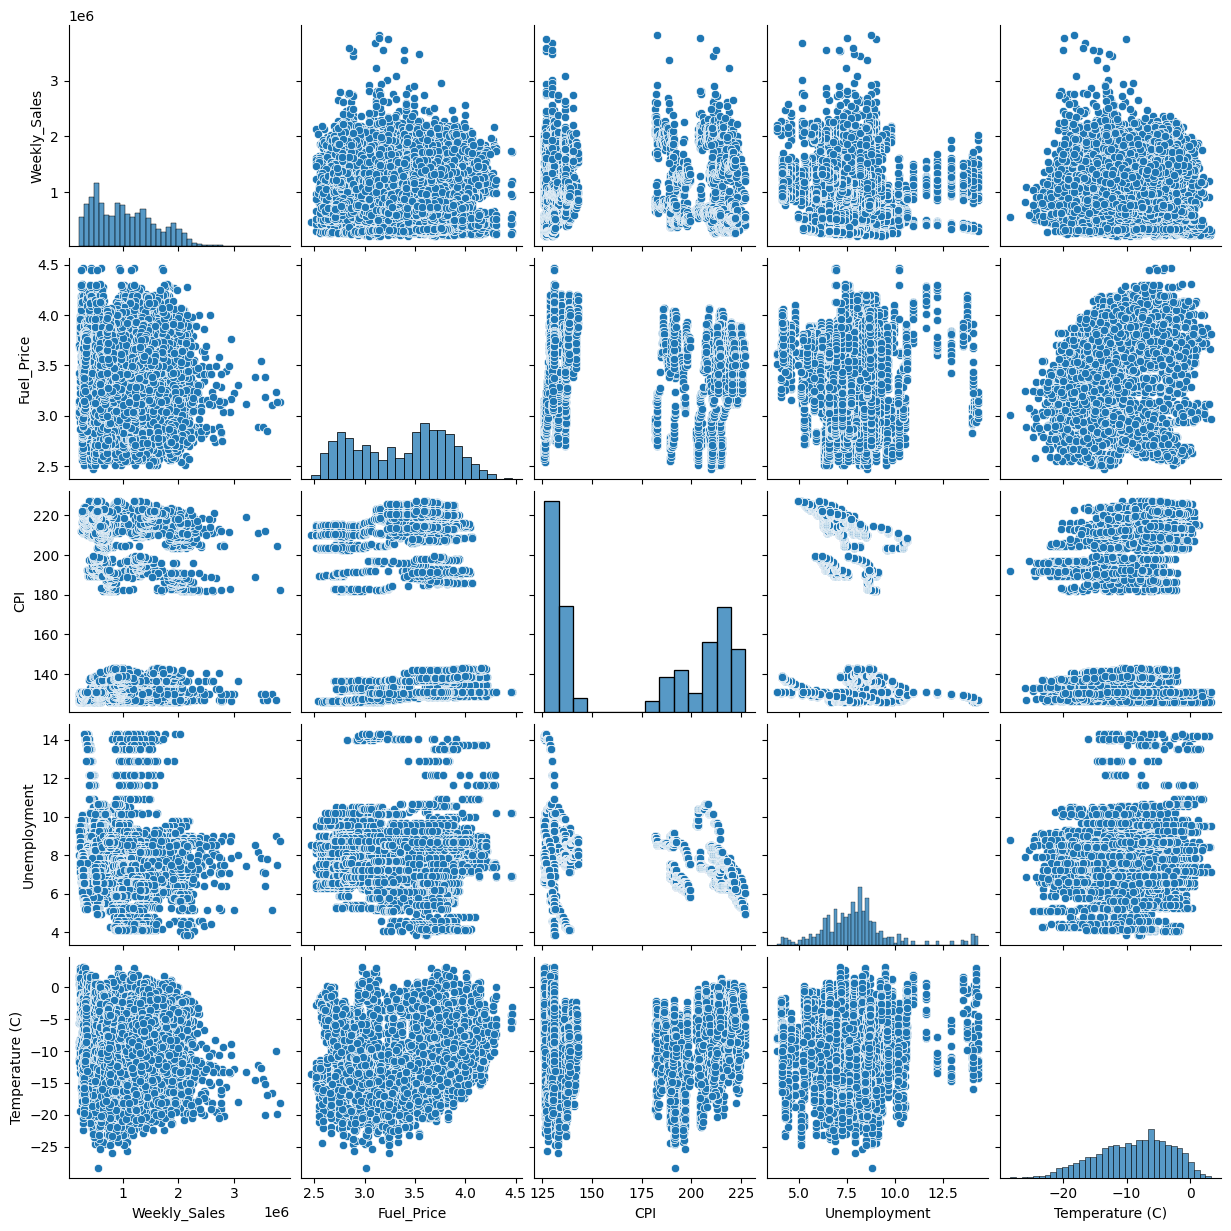

In [38]:
sns.pairplot(weekly_sales)

In [40]:
sales_df['Store'].nunique()

45

<bound method Axes.set of <Axes: title={'center': 'Weekly Sales Over Time by Store'}, xlabel='Date', ylabel='Weekly_Sales'>>

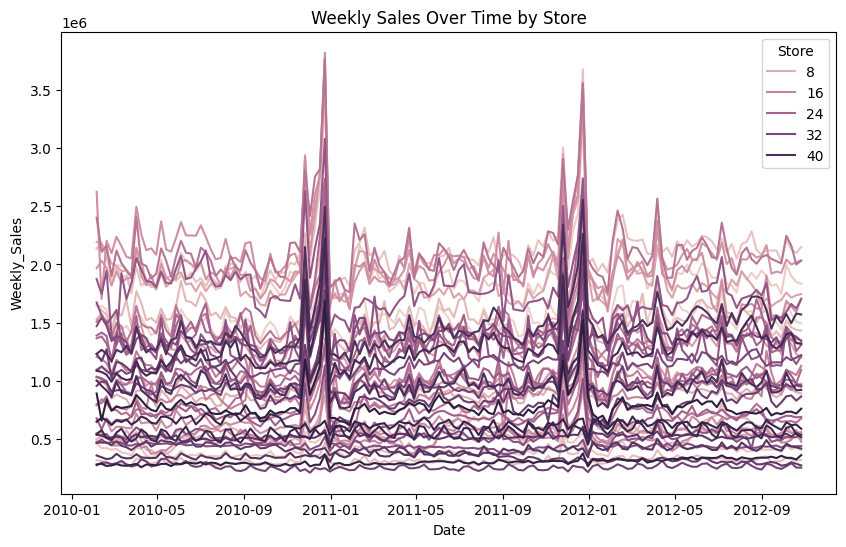

In [41]:
fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(x='Date', y='Weekly_Sales', hue='Store', data=sales_df, ax=ax)
ax.set_title('Weekly Sales Over Time by Store')
ax.set

In [45]:
sales_df.groupby('Holiday_Flag')['Weekly_Sales'].describe()

,count,mean,std,min,25%,50%,75%,max
Holiday_Flag,,,,,,,,
0,5985.0,1.041256e+06,558957.436147,209986.25,551378.3900,956211.20,1414343.530,3818686.45
1,450.0,1.122888e+06,627684.931884,215359.21,575865.4825,1018538.04,1555213.175,3004702.33


In [48]:
# Look at which store has the most sales
sales_df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08
10,2.716177e+08
27,2.538559e+08
6,2.237561e+08
1,2.224028e+08


In [50]:
sales_df.to_csv('Cleaned-Sales-Data.csv', index = False)